<a href="https://colab.research.google.com/github/andresjg27/BNS-Merger-Rate-Population-Code/blob/main/Andres_Merger_Rate_Code_Clean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Importing Stuff



In [1]:
#importing files, some may not be used
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import seaborn as sns
from astropy.cosmology import WMAP9 as cosmo
import astropy.units as u
from astropy.cosmology import Planck13, z_at_value
import scipy as sp

!pip install pycbc lalsuite ligo-common seaborn
! git clone https://gitlab.com/jocelyn.read/cosmic-explorer-data-references.git
# Only needs to be done once
! ls cosmic-explorer-data-references
#testing to see if data can be retrieved

fatal: destination path 'cosmic-explorer-data-references' already exists and is not an empty directory.
DTD_ndot        README.md       common-3g-data  curves_May_2019 postmerger-refs


In [2]:
import pycbc
from pycbc.conversions import mchirp_from_mass1_mass2
from pycbc import types, fft, waveform
from pycbc.waveform import get_fd_waveform
from pycbc import psd
from pycbc.filter.matchedfilter import sigmasq

/opt/miniconda3/envs/gwenv/lib/python3.10/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal
PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1
/opt/miniconda3/envs/gwenv/lib/python3.10/site-packages/pycbc/waveform/plugin.py:99: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30

##Observatory Noise Curves


advirgo.txt       aplus_sqzonly.txt kagra_sqz.txt     o3_l1.txt
advirgo_sqz.txt   ce.txt            kagra_wb.txt      o3_v1.txt
advirgo_wb.txt    ce_wb.txt         o1.txt            s6.txt
aligo.txt         er8.txt           o2.txt            voyager.txt
aligo_design.txt  et_d.txt          o2_crossspec.txt
aplus.txt         kagra.txt         o3_h1.txt
0 ALIGO cosmic-explorer-data-references/curves_May_2019/aligo.txt
1 APLUS cosmic-explorer-data-references/curves_May_2019/aplus.txt
2 Voyager cosmic-explorer-data-references/curves_May_2019/voyager.txt
3 CE cosmic-explorer-data-references/curves_May_2019/ce_wb.txt


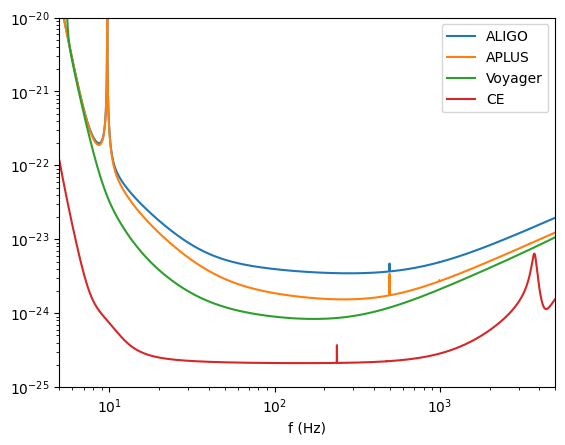

In [3]:
! ls cosmic-explorer-data-references/curves_May_2019
# https://dcc.ligo.org/LIGO-T1500293/public

DetectorNames = ["ALIGO","APLUS","Voyager","CE"]
DetectorFiles = ["aligo.txt","aplus.txt","voyager.txt","ce_wb.txt"]

DetectorASDDataList = []
for i, detname in enumerate(DetectorNames):
  print(i,detname,"cosmic-explorer-data-references/curves_May_2019/"+DetectorFiles[i])
  psddata = np.genfromtxt("cosmic-explorer-data-references/curves_May_2019/"+DetectorFiles[i])
  DetectorASDDataList.append(psddata)
DetectorASDData = dict(zip(DetectorNames, DetectorASDDataList))

for detname in DetectorNames:
  plt.loglog(np.append(DetectorASDData[detname][:,0],16*2048),
    np.append(DetectorASDData[detname][:,1],1.e-22),label=detname)
  # WILL NEED HIGH FREQUENCY FOR NS MERGER CALCULATIONS
  # Add a high-frequency point to everything that behaves reasonably [HACK]
  # CE - skyloc dependent noise curve, may need to implement following https://arxiv.org/abs/1708.06843
plt.legend()
plt.ylim(1e-25,1e-20)
plt.xlim(5,5000)
plt.xlabel("f (Hz)")

#VOyager is basically Asharp - telescope between now and CE ~3 orders of magnitude improvement - less rane more precise
#Could also see what % of grb are pointed at us

DetectorPSDDataList=[]
  # Add a high-frequency point to everything that behaves reasonably [HACK]
for detname in DetectorNames:
  PSD = np.array((
      np.append(DetectorASDData[detname][:,0],16*2048),
    np.power(np.append(DetectorASDData[detname][:,1],1.e-22),2))).T
  DetectorPSDDataList.append(PSD)
DetectorPSDData = dict(zip(DetectorNames, DetectorPSDDataList))

##Mass Models


Text(0.5, 1.0, 'NS Mass Distributions')

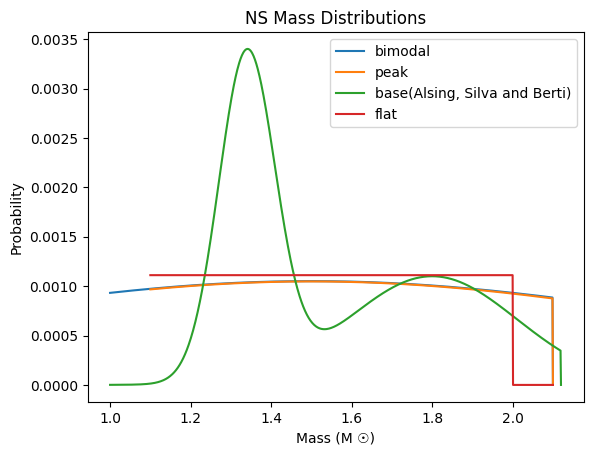

In [4]:
#I'm going to create a numpy array with the values and uncertainties from Table 1
#it will be arranged as follows (mmin, mmax, mu1, sig1, mu2, sig2, w?)
flat_params = np.array(((1.1,0.2,-0.1),(2.0,0.4,-0.3)))
peak_params = np.array(((1.1,0.2,-0.1),(2.1,0.7,-0.3),(1.5,0.5,-0.3),(1.0,0.9,-0.7)))
bimodal_params = np.array(((1.0,0,0),(2.1,0.7,-0.3),(1.3,0.5,-0.3),(1.0,0.9,-0.8),(1.7,0.6,-0.4),(1.0,0.9,-0.9),(0.5,0.5,-0.4)))

qflat_params = np.array(((1.1,0.1,-0.2),(2.0,0.3,-0.3)))
qpeak_params = np.array(((1.1,0.2,-0.1),(2.1,0.7,-0.2),(1.5,0.5,-0.3),(1.0,0.9,-0.7)))
qbimodal_params = np.array(((1.0,0,0),(2.1,0.7,-0.3),(1.3,0.5,-0.3),(0.9,1.0,-0.8),(1.7,0.5,-0.4),(1.0,0.9,-0.9),(0.5,0.5,-0.4)))

#defining my gaussian curve
def gaussian(x, mu, sig):
    return 1./(np.sqrt(2.*np.pi)*sig)*np.exp(-np.power((x - mu)/sig, 2.)/2)
bimodal_mmin = bimodal_params[0,0]
bimodal_mmax = bimodal_params[1,0]
peak_mmin = peak_params[0,0]
peak_mmax = peak_params[1,0]
flat_mmin = flat_params[0,0]
flat_mmax = flat_params[1,0]
def bimodal_mass(m):
  if m < bimodal_mmax:
    return gaussian(m, bimodal_params[2,0], bimodal_params[3,0]) + gaussian(m, bimodal_params[4,0], bimodal_params[5,0])
  return 0
def peak_mass(m):
  if m < peak_mmax:
    return gaussian(m,peak_params[2,0], peak_params[3,0])
  return 0
def flat_mass(m):
  if m < flat_mmax:
    return 1/(flat_mmax-flat_mmin)
  return 0

#gonna plot the data now hope it works
#create my linspace so my gaussian has something to plot to
bimodal_NSmasses = np.linspace(bimodal_mmin,bimodal_mmax, 1000)
bimodal_mass_dist = [bimodal_mass(m) for m in bimodal_NSmasses]
#below to normalize
bimodal_mass_dist = bimodal_mass_dist/np.sum(bimodal_mass_dist)

peak_NSmasses = np.linspace(peak_params[0,0], peak_params[1,0], 1000 )
peak_mass_dist = [peak_mass(m) for m in peak_NSmasses]
peak_mass_dist = peak_mass_dist/np.sum(peak_mass_dist)

flat_NSmasses = np.linspace(flat_params[0,0], peak_params[1,0],1000)
flat_mass_dist = [flat_mass(m) for m in flat_NSmasses]
flat_mass_dist = flat_mass_dist/np.sum(flat_mass_dist)



#Dr. Read Code
twogaussian_mmax_params = np.array((
(1.34,0.03, -0.02 ),
(1.80,0.15, -0.18 ),
(0.07,0.02, -0.02 ),
(0.21,0.18,-0.14 ),
(0.65,0.08,-0.15 ),
(2.12,0.09,-0.12))
)

def gaussian(x, mu, sig):
    return 1./(np.sqrt(2.*np.pi)*sig)*np.exp(-np.power((x - mu)/sig, 2.)/2)
mmaxNS = twogaussian_mmax_params[-1,0]
mminNS = 1.0
def massmodel(m):
    if m < mmaxNS:
      return gaussian(m, twogaussian_mmax_params[0,0],twogaussian_mmax_params[2,0]) + gaussian(m, twogaussian_mmax_params[1,0],twogaussian_mmax_params[3,0])
    return 0
baseNSmasses = np.linspace(mminNS,mmaxNS,1000)
NSmassdist = [massmodel(m) for m in baseNSmasses]
NSmassdist = NSmassdist/np.sum(NSmassdist)

#now this is a plot

plt.plot(bimodal_NSmasses,bimodal_mass_dist,label='bimodal')
plt.plot(peak_NSmasses, peak_mass_dist,label='peak')
plt.plot(baseNSmasses, NSmassdist, label='base(Alsing, Silva and Berti)' )
plt.plot(flat_NSmasses,flat_mass_dist, label='flat')
plt.xlabel('Mass (M ☉)')
plt.ylabel('Probability')
plt.legend()
plt.title('NS Mass Distributions')

##SFR

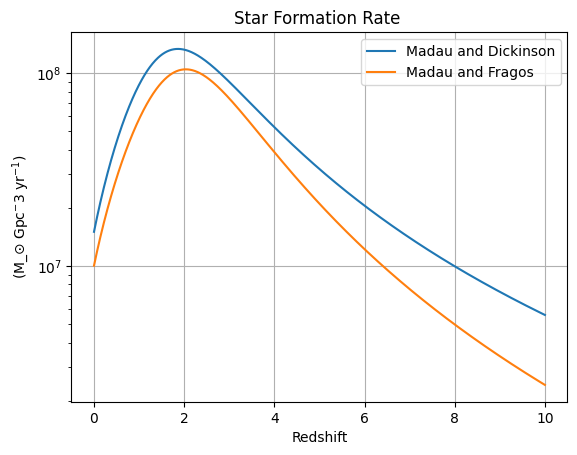

In [5]:
redshift_basevals = np.linspace(0.001,10,1000)
#sfr from madau and dickinson
def sfr(zb):
  if zb > 0:
    return (0.015 * ((1+zb) ** 2.7)/(1+(((1+zb)/2.9) ** 5.6))) * 10**9

sfr_history = [sfr(z) for z in redshift_basevals]

#below is from Madau and Fragos 2017 https://iopscience.iop.org/article/10.3847/1538-4357/aa6af9 (Zevin uses this)

def sfr_mf(z):
      return (0.01 * ((1+z) ** 2.6)/(1+(((1+z)/3.2) ** 6.2))) * 10**9
sfr_mf_bins = [sfr_mf(z) for z in redshift_basevals]


plt.plot(redshift_basevals, sfr_history, label='Madau and Dickinson')
plt.plot(redshift_basevals, sfr_mf_bins, label = 'Madau and Fragos' )
plt.xlabel('Redshift')
plt.ylabel('(M_${\odot}$ Gpc$^{-}3$ yr$^{-1}$)')
#plt.yscale('log')
plt.legend()
plt.title('Star Formation Rate ')
plt.grid()
plt.yscale('log')

#plt.xlim(2,10)
#plt.ylim(10e-4,0)

##Delay Time Distribution

9.210340371976205
7.244227515603349


/var/folders/v2/sqb0b1055zd7wgsnsmjgfbf00000gn/T/ipykernel_21300/3407116518.py:50: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  norm_20 = 1/(sp.integrate.quad(dtd_20, 0.01*10**9, 100*10**9)[0])


Text(0.5, 1.0, 'Delay Time Distributions with Different Slopes and tmin = 10Myr, tmin = 100Myr')

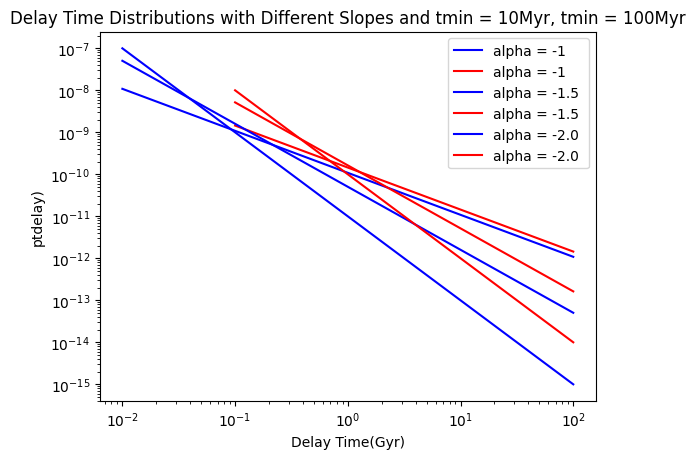

In [6]:

N = ((np.log10(100/0.01))**-1) #normalization constant data #does NOT work but Zevin uses it (allegedely)
#Delay times for tmin=10Myr
delaytimesyr = np.linspace(0.01*10**9,100*10**9, 1000000)
delaytimesGPC = np.linspace(0.010,100, 1000000)

#Delay times for tmin = 100 Myr
delaytimesyr2 = np.linspace(0.1*10**9,100*10**9, 1000000)
delaytimesGPC2 = np.linspace(0.1,100, 1000000)
#SLOPE -1
def dtd(t,tmin,tmax):
  if tmin <= t <= tmax:
    return ((((t) ** -1)))

dtdstandard = [dtd(t, 0.01*10**9, 100*10**9)* 1/9.210340371976203 for t in delaytimesyr]
dtdstandard2 = [dtd(t, 0.1*10**9, 100*10**9) for t in delaytimesyr]

def dtd_equation(x):
  return 1/x

Norm = sp.integrate.quad(dtd_equation, 0.01*10**9, 100*10**9)
print(Norm[0])

Norm2 = sp.integrate.quad(dtd_equation, 0.1*10**9, 100*10**9)

dtdstandard = [dtd(t, 0.01*10**9, 100*10**9)* 1/Norm[0] for t in delaytimesyr]
dtdstandard2 = [dtd(t, 0.1*10**9, 100*10**9)* 1/Norm2[0]for t in delaytimesyr2]

#DTD normalization for my data
Norm_fiducial = sp.integrate.quad(dtd_equation, 0.01*10**9, 14*10**9)
print(Norm_fiducial[0])

dtd_norm_fiducial = 1/7.244227515603351

#SLOPE -1.5

def dtd_15(t):
  return t ** (-1.5)

norm_15 = 1/(sp.integrate.quad(dtd_15, 0.01*10**9, 100*10**9)[0])
norm_152 = 1/(sp.integrate.quad(dtd_15, 0.1*10**9, 100*10**9)[0])

delaytimes_15 = [dtd_15(t)*norm_15 for t in delaytimesyr]
delaytimes_152 = [dtd_15(t)*norm_152 for t in delaytimesyr2]

#SLOPE -2

def dtd_20(t):
  return t ** (-2)

norm_20 = 1/(sp.integrate.quad(dtd_20, 0.01*10**9, 100*10**9)[0])
norm_202 = 1/(sp.integrate.quad(dtd_20, 0.1*10**9, 100*10**9)[0])

delaytimes_20 = [dtd_20(t)*norm_20 for t in delaytimesyr]
delaytimes_202 = [dtd_20(t)*norm_202 for t in delaytimesyr2]

plt.loglog(delaytimesGPC, dtdstandard, label = 'alpha = -1', color = 'b')
plt.loglog(delaytimesGPC2, dtdstandard2, label = 'alpha = -1', color = 'red')
plt.loglog(delaytimesGPC, delaytimes_15, label = 'alpha = -1.5 ', color = 'b')
plt.loglog(delaytimesGPC2, delaytimes_152, label = 'alpha = -1.5 ', color = 'red')
plt.loglog(delaytimesGPC, delaytimes_20, label = 'alpha = -2.0 ', color = 'b')
plt.loglog(delaytimesGPC2, delaytimes_202, label = 'alpha = -2.0 ', color = 'red')

plt.ylabel('ptdelay)')
plt.xlabel('Delay Time(Gyr)')
plt.legend()
plt.title('Delay Time Distributions with Different Slopes and tmin = 10Myr, tmin = 100Myr')
#plt.xlim(2,10)
#plt.ylim(10e-13,10e-8)
#(We don't know the sfr well enough to claim certain things about measurement we just wanna be careful to say how changes in the dtd affect r process stuff)

In [7]:
def dtd(t, slope):
  return t**slope

def normalization(tmin, tmax):
  return sp.integrate.quad(dtd, tmin*10**9, tmax*10**9)

def dtd_process(t, slope, tmin, tmax):
    def dtd(t, slope):
      return t**slope
    def normalization(t, slope, tmin, tmax):
      return sp.integrate.quad(dtd, tmin*10**9, tmax*10**9, args = (slope))[0]

    return dtd(t,slope)/normalization(t, slope, tmin, tmax)






##Merger Rate Code

In [8]:
#Unit conversions
sfr_to_Gpc = 10**9
H0 = cosmo.H0.to(1/u.Gyr).value

print('conversion from H0 to H0 in Gyr is ', cosmo.H0.value/cosmo.H0.to(1/u.Gyr).value)
print(cosmo.H0.value/977.79)
cosmo_H0to_Gyr = 977.79

conversion from H0 to H0 in Gyr is  977.7922216807892
0.07089456836335


In [11]:
def mergerrate(zm, slope, tmin, tmax): #zm is the z at merger

  def sfr_in_use(z):
      return (0.01 * ((1+z) ** 2.6)/(1+(((1+z)/3.2) ** 6.2))) # Madau and fragos

  def plbmdt(z, zm, slope, tmin, tmax):
    a = ((((cosmo.lookback_time(zm) - cosmo.lookback_time(z))/u.Gyr - tmin))** -slope) # Safarzadeh has a similar subtraction in their dtd parameterization but they use 0.01, so I assume Zevin does the same thing implicitly

    if  cosmo.lookback_time(zm)/u.Gyr - tmax <=  ((cosmo.lookback_time(zm) - cosmo.lookback_time(z))/u.Gyr) <= cosmo.lookback_time(zm)/u.Gyr - tmin:
     return a
    else:
      return 0

  def dtdz(z):
    return ((cosmo.H0.value * (((cosmo.Om0 * (((1+z) ** 3))) + cosmo.Ode0 * (z))**0.5) * (1+z)) ** -1)

  def ndotintegrand(z):
    return ( plbmdt(z, zm, 1, tmin, tmax) * 10**-5 * sfr_in_use(z) * dtdz(z))

  def dtd(t, slope):
      return t**slope

  def normalization(slope, tmin, tmax):
      return 1/(sp.integrate.quad(dtd, tmin*10**9, tmax*10**9, args = (slope))[0])

  I = sp.integrate.quad(ndotintegrand, np.inf, zm)[0]

  return (I * normalization(slope, tmin, tmax) * cosmo_H0to_Gyr * sfr_to_Gpc)

redshift_basevals = np.linspace(0.001,10,1000)
ndotvalues = [mergerrate(zm, -1, 0.01, 14) for zm in redshift_basevals]

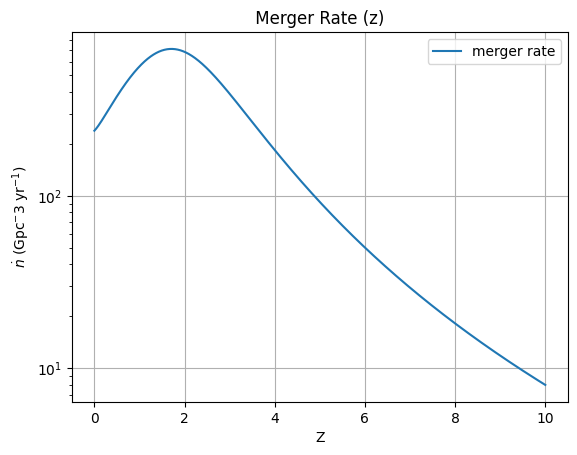

In [13]:
plt.plot(redshift_basevals, ndotvalues, label='merger rate')
plt.ylabel('$\dot{n}$ (Gpc$^{-}3$ yr$^{-1}$)')
plt.xlabel('Z')
plt.yscale('log')
plt.legend()
plt.title(' Merger Rate (z) ')

#plt.xlim(0,10)
#plt.ylim(10,20e2)
plt.grid(True, axis = 'both')

In [ ]:
#Comparison to SFR
fig, ax1 = plt.subplots()
ax1.set_xlabel('z')
ax1.set_ylabel('$\dot{n}$ (Gpc$^{-}3$ yr$^{-1}$)')
ax1.plot(redshift_basevals, ndotvalues, color = 'black', label = '$\dot{n}$')
ax1.set_yscale('log')
ax1.set_xlim(0,10)
ax1.set_ylim(10, 2000)
ax1.legend()
ax1.grid(axis = 'y')
ax1.grid(axis = 'x')

ax2 = ax1.twinx()

color = 'tab:black'
ax2.set_ylabel('(M_${\odot}$ Gpc$^{-}3$ yr$^{-1}$)')
ax2.plot(redshift_basevals,sfr_mf_bins, color = 'black', label = 'Star Formation Rate', linestyle = 'dotted')
ax2.set_yscale('log')
ax2.set_ylim(1e6, 19e7)
plt.title('BNS Merger Rate and Star Formation Rate')
ax2.legend(loc = 'lower right')
ax1.grid(axis = 'y')
ax2.grid(axis = 'x')


##Population Code

In [ ]:
dz_base = redshift_basevals[1] #maybe wanna subtract the reshift basevals [0] to get the step size

lumdist_basevals = cosmo.luminosity_distance(redshift_basevals).value
scale_factor_basevals =   cosmo.scale_factor(redshift_basevals)
diff_Vc_basevals = 4.0 * np.pi * (cosmo.differential_comoving_volume(redshift_basevals).value)
#above is 4 pi r? maybe should be 4pi r squared?

plt.loglog(redshift_basevals,lumdist_basevals)
plt.xlabel("redshift $z$")
plt.ylabel("$D_L$ (Mpc)")
plt.grid()

In [ ]:
#adjusting for local rate

localrate = 200 / np.power(1000,3) # rate / Gpc^3 / yr , converted to 1000^3 Mpc^3 / Gpc^3

rate_scale = localrate / mergerrate(0.01)*10**9 ##multiply by 10**9 to get it in Mpc
print("Scaling to estimated local rate", localrate ,"requires a factor of",rate_scale)

In [ ]:
plt.plot(redshift_basevals, rate_scale*np.array(ndotvalues))
plt.xlabel("redshift $z$")
plt.ylabel("$\dot{n}$ (Gpc$^{-}3$ yr$^{-1}$)")
plt.title('Merger Rate Over Z adjusted for local rate')

In [ ]:
dNdz_basevals = diff_Vc_basevals * ndotvalues *10**-9 / scale_factor_basevals
plt.loglog(redshift_basevals, dNdz_basevals ,label="Mergers per unit z")
plt.loglog(redshift_basevals, mergerrate(0.01) *10**-9* diff_Vc_basevals/ scale_factor_basevals,label="Constant local rate")
plt.xlabel("Redshift $z$")
plt.ylabel("Mergers per unit z per year")
plt.legend()
plt.xlim(0.01,10)
plt.ylim(10,13e6)

In [ ]:
dz_base = (redshift_basevals[1]-redshift_basevals[0])
totalmergers = rate_scale * sum(dNdz_basevals) * dz_base

print('total mergers ->',totalmergers,'sum Dndz basevals ->', sum(dNdz_basevals),'dz base->', dz_base, 'rate scale->', rate_scale )

###Rate Statements


In [ ]:
print("There are" ,'{0:1.2g}'.format(totalmergers), "DNS merger GWs per year from this Universe.")
print("There are" ,'{0:1.2g}'.format(totalmergers/365*7), "DNS merger GWs per week from this Universe.")
print("There are" ,'{0:1.2g}'.format(totalmergers/365), "DNS merger GWs per day from this Universe.")
print("There are" ,'{0:1.2g}'.format(totalmergers/365/24), "DNS merger GWs per hour from this Universe.")
print("There are" ,'{0:1.2g}'.format(totalmergers/365/24/60), "DNS merger GWs per minute from this Universe.")

In [ ]:
 nearred = 0.2
nearbymergers = rate_scale * sum(dNdz_basevals[redshift_basevals<nearred]) * redshift_basevals[1]
print("There are" ,'{0:1.2g}'.format(nearbymergers), "DNS GWs per year with z<",nearred)
print("There are" ,'{0:1.2g}'.format(nearbymergers/365*7), "DNS GWs per week with z<",nearred)
print("There are" ,'{0:1.2g}'.format(nearbymergers/365), "DNS GWs per day with z<",nearred)
print("There are" ,'{0:1.2g}'.format(nearbymergers/365/24), "DNS GWs per hour with z<",nearred)
print ("( or D <",'{0:1.3g}'.format(cosmo.luminosity_distance(nearred).value), "Mpc)")

In [ ]:
nearred = 0.1
nearbymergers = rate_scale * sum(dNdz_basevals[redshift_basevals<nearred]) * redshift_basevals[1]
print("There are" ,'{0:1.2g}'.format(nearbymergers), "DNS mergers per year with z <",nearred)
print("There are" ,'{0:1.2g}'.format(nearbymergers/365*7), "DNS mergers per week with z <",nearred)
print("There are" ,'{0:1.2g}'.format(nearbymergers/365), "DNS mergers per day with z <",nearred)
print("There are" ,'{0:1.2g}'.format(nearbymergers/365/24), "DNS mergers per hour with z <",nearred)
print ("( or D <",'{0:1.3g}'.format(cosmo.luminosity_distance(nearred).value), "Mpc)")

In [ ]:
#local rate statistics
print("Constant rate of",'{0:1.3g}'.format(localrate*np.power(1000.,3)),"/ Gpc^3 / yr, with cosmological volume:")
for nearred in (0.01,0.05,0.1):
  print(" . ",'{0:1.2g}'.format(cosmo.comoving_volume(nearred).value * localrate),
        "per year with z <",nearred, "and D <",'{0:1.3g}'.format(cosmo.luminosity_distance(nearred).value), "Mpc")

In [ ]:
print("GW170817-like signal every ",1 /( cosmo.comoving_volume(0.01).value * localrate),"years.")

In [ ]:
redshift_plot = np.linspace(0,1,21)
ratebins_plot = np.array([rate_scale * sum(dNdz_basevals[redshift_basevals<rs])* dz_base for rs in redshift_plot])

plt.bar(redshift_plot[1:],ratebins_plot[1:] - ratebins_plot[:-1],width=1)
plt.grid()
plt.yscale('log')

In [ ]:
nsamples = 840000 # Can't really resolve both CE and ALIGO;
# I'll just look at subpopulations below, but there is probably a clever analytic way to do this
near = 0.5
sampletime = nsamples/ (rate_scale * sum(dNdz_basevals) * dz_base)
sampletime_nearby = nsamples/(rate_scale * sum(dNdz_basevals[redshift_basevals<near]) * dz_base)
print(nsamples,"mergers occur every ",'{0:1.3g}'.format(sampletime*365), "days in the Universe")
print(nsamples,"mergers occur every ",'{0:1.3g}'.format(sampletime_nearby) , "years with z <",near)


In [ ]:
fiducial_time = 5 # five year survey
nearby_survey = int(nsamples * fiducial_time / sampletime_nearby)
print(nearby_survey)

# Intrinsic parameters

In [ ]:
mAs = np.random.choice(baseNSmasses,nsamples, p=bimodal_mass_dist)
mBs = np.random.choice(baseNSmasses,nsamples, p=bimodal_mass_dist)
# independent draws from the distribution
#swap out for other mass models
#using bimodal mass distribution parameters from Landry and Read

In [ ]:
mheavy = np.array([max(massA, massB) for (massA, massB) in np.array((mAs, mBs)).T])
mlight = np.array([min(massA, massB) for (massA, massB) in np.array((mAs, mBs)).T])

In [ ]:
mchirps = [mchirp_from_mass1_mass2(mass1, mass2) for (mass1, mass2) in np.array((mAs, mBs)).T]
mchirps = np.array(mchirps)

In [ ]:
sns.distplot(mchirps)
plt.xlabel("$\mathcal{M}$")
plt.axvline(1.44,color="green")
plt.axvline(1.188,color="green")
plt.annotate('GW170817',xy=(1.1892,1))
plt.annotate('GW190425',xy=(1.444,1))

# Statistics

to work on  1. Dont just limit to z=3

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import json
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
# Define the file path in Google Drive (must be the same path used for saving)
file_path = '/content/drive/My Drive/Asharp10.json'

# Read the data from the JSON file
with open(file_path, 'r') as f:
    Asharp10 = json.load(f) # Use json.load() to read data from the file

In [ ]:
len(Asharp10)

In [ ]:
# Define the file path in Google Drive (must be the same path used for saving)
file_path = '/content/drive/My Drive/Asharp20.json'

# Read the data from the JSON file
with open(file_path, 'r') as f:
    Asharp20 = json.load(f) # Use json.load() to read data from the file


#bins calculation
from astropy.stats import freedman_bin_width
freedman_bin_width(Asharp10)
bins = int((max(Asharp10) - min(Asharp10))/freedman_bin_width(Asharp10))
print(bins)
bins = np.linspace(0,4, 20)
p, _ = np.histogram(Asharp10, bins=bins, density=True)
q, _ = np.histogram(Asharp20, bins=bins, density=True)

# 3. Handle Zero Probabilities (KL divergence is undefined for Q(i)=0)
# Add a small epsilon to avoid division by zero or log(0)
epsilon = 1e-10
p = p + epsilon
q = q + epsilon
p = p / np.sum(p) # Renormalize
q = q / np.sum(q)

# 4. Calculate KL Divergence
kl_pq = stats.entropy(p, q) # Base e (nats)
# kl_pq_bits = stats.entropy(p, q, base=2) # Use base 2 for bits

print(f"KL Divergence (P || Q): {kl_pq:.4f} nats")
plt.hist(Asharp10,bins = bins, density = True)
plt.hist(Asharp20, bins = bins, density = True)
plt.title('10 Mgy vs 20Mgy Delay Time')
plt.xlabel('Effective Distance (Gpc)')
plt.ylabel('Number of Detections')

In [ ]:
import json

# Define the file path in Google Drive (must be the same path used for saving)
file_path = '/content/drive/My Drive/ten_one.json'

# Read the data from the JSON file
with open(file_path, 'r') as f:
    ten_one = json.load(f) # Use json.load() to read data from the file

print("List successfully loaded from the file:")

In [ ]:
import json

# Define the file path in Google Drive (must be the same path used for saving)
file_path = '/content/drive/My Drive/ten_one.json'

# Read the data from the JSON file
with open(file_path, 'r') as f:
    ten_one = json.load(f) # Use json.load() to read data from the file

print("List successfully loaded from the file:")


In [ ]:
# Define the file path in Google Drive (must be the same path used for saving)
file_path = '/content/drive/My Drive/eleven_one.json'

# Read the data from the JSON file
with open(file_path, 'r') as f:
    eleven_one = json.load(f) # Use json.load() to read data from the file



In [ ]:
# Define the file path in Google Drive (must be the same path used for saving)
file_path = '/content/drive/My Drive/twenty_one.json'

# Read the data from the JSON file
with open(file_path, 'r') as f:
    twenty_one = json.load(f) # Use json.load() to read data from the file



In [ ]:
# Define the file path in Google Drive (must be the same path used for saving)
file_path = '/content/drive/My Drive/fifteen_one.json'

# Read the data from the JSON file
with open(file_path, 'r') as f:
    fifteen_one = json.load(f) # Use json.load() to read data from the file


In [ ]:
#bins calculation
from astropy.stats import freedman_bin_width
freedman_bin_width(ten_one)
bins = int((max(ten_one) - min(ten_one))/freedman_bin_width(ten_one))
print(bins)

In [ ]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
# [two sets of data data1 and data2]
# 2. Create Histograms (normalized to form probability distributions)
# Ensure both use the same bins
bins = bins
p, _ = np.histogram(ten_one, bins=bins, density=True)
q, _ = np.histogram(eleven_one, bins=bins, density=True)

# 3. Handle Zero Probabilities (KL divergence is undefined for Q(i)=0)
# Add a small epsilon to avoid division by zero or log(0)
epsilon = 1e-10
p = p + epsilon
q = q + epsilon
p = p / np.sum(p) # Renormalize
q = q / np.sum(q)

# 4. Calculate KL Divergence
kl_pq = stats.entropy(p, q) # Base e (nats)
# kl_pq_bits = stats.entropy(p, q, base=2) # Use base 2 for bits

print(f"KL Divergence (P || Q): {kl_pq:.4f} nats")

In [ ]:
plt.hist(ten_one,bins = bins, density = True)
plt.hist(eleven_one, bins = bins, density = True)
plt.title('10 Mgy vs 20 Mgy Delay Time')
plt.xlabel('Effective Distance (Gpc)')
plt.ylabel('Number of Detections')

In [ ]:
p, _ = np.histogram(ten_one, bins=bins, density=True)
q, _ = np.histogram(fifteen_one, bins=bins, density=True)

# 3. Handle Zero Probabilities (KL divergence is undefined for Q(i)=0)
# Add a small epsilon to avoid division by zero or log(0)
epsilon = 1e-10
p = p + epsilon
q = q + epsilon
p = p / np.sum(p) # Renormalize
q = q / np.sum(q)

# 4. Calculate KL Divergence
kl_pq = stats.entropy(p, q) # Base e (nats)
# kl_pq_bits = stats.entropy(p, q, base=2) # Use base 2 for bits

print(f"KL Divergence (P || Q): {kl_pq:.4f} nats")

In [ ]:
plt.hist(ten_one,bins = bins, density = True)
plt.hist(fifteen_one, bins = bins, density = True)
plt.title('10 Mgy vs 15 Mgy Delay Time')
plt.xlabel('Effective Distance (Gpc)')
plt.ylabel('Number of Detections')

In [ ]:
p, _ = np.histogram(ten_one, bins=bins, density=True)
q, _ = np.histogram(twenty_one, bins=bins, density=True)

# 3. Handle Zero Probabilities (KL divergence is undefined for Q(i)=0)
# Add a small epsilon to avoid division by zero or log(0)
epsilon = 1e-10
p = p + epsilon
q = q + epsilon
p = p / np.sum(p) # Renormalize
q = q / np.sum(q)

# 4. Calculate KL Divergence
kl_pq = stats.entropy(p, q) # Base e (nats)
# kl_pq_bits = stats.entropy(p, q, base=2) # Use base 2 for bits

print(f"KL Divergence (P || Q): {kl_pq:.4f} nats")

kl_pq * len(ten_one)

In [ ]:
plt.hist(ten_one,bins = bins, density = True, label = '10 Mgy')
plt.hist(twenty_one, bins = bins, density = True, label = '20 Mgy')
plt.title('10 Mgy vs 20 Mgy Delay Time')
plt.xlabel('Effective Distance (Gpc)')
plt.ylabel('Density')
plt.legend()

In [ ]:
print(ten_one == eleven_one)
print(ten_one == fifteen_one)
print(ten_one == ten01_one)
print(ten_one == twenty_one)

In [ ]:
# Define the file path in Google Drive (must be the same path used for saving)
file_path = '/content/drive/My Drive/ten01_one.json'

# Read the data from the JSON file
with open(file_path, 'r') as f:
    ten01_one = json.load(f) # Use json.load() to read data from the file



p, _ = np.histogram(ten_one, bins=bins, density=True)
q, _ = np.histogram(ten01_one, bins=bins, density=True)

# 3. Handle Zero Probabilities (KL divergence is undefined for Q(i)=0)
# Add a small epsilon to avoid division by zero or log(0)
epsilon = 1e-10
p = p + epsilon
q = q + epsilon
p = p / np.sum(p) # Renormalize
q = q / np.sum(q)

# 4. Calculate KL Divergence
kl_pq = stats.entropy(p, q) # Base e (nats)
# kl_pq_bits = stats.entropy(p, q, base=2) # Use base 2 for bits

print(f"KL Divergence (P || Q): {kl_pq:.4f} nats")
plt.hist(ten_one,bins = bins, density = True)
plt.hist(ten01_one, bins = bins, density = True)
plt.title('10 Mgy vs 10.1Mgy Delay Time')
plt.xlabel('Effective Distance (Gpc)')
plt.ylabel('Number of Detections')

In [ ]:
# Define the file path in Google Drive (must be the same path used for saving)
file_path = '/content/drive/My Drive/d01001_one.json'

# Read the data from the JSON file
with open(file_path, 'r') as f:
    d01001_one = json.load(f) # Use json.load() to read data from the file



p, _ = np.histogram(ten_one, bins=bins, density=True)
q, _ = np.histogram(d01001_one, bins=bins, density=True)

# 3. Handle Zero Probabilities (KL divergence is undefined for Q(i)=0)
# Add a small epsilon to avoid division by zero or log(0)
epsilon = 1e-10
p = p + epsilon
q = q + epsilon
p = p / np.sum(p) # Renormalize
q = q / np.sum(q)

# 4. Calculate KL Divergence
kl_pq = stats.entropy(p, q) # Base e (nats)
# kl_pq_bits = stats.entropy(p, q, base=2) # Use base 2 for bits

print(f"KL Divergence (P || Q): {kl_pq:.4f} nats")
plt.hist(ten_one,bins = bins, density = True)
plt.hist(d01001_one, bins = bins, density = True)
plt.title('10 Mgy vs 10.01Mgy Delay Time')
plt.xlabel('Effective Distance (Gpc)')
plt.ylabel('Number of Detections')

In [ ]:
#With self should be zero nats

p, _ = np.histogram(ten_one, bins=bins, density=True)
q, _ = np.histogram(ten_one, bins=bins, density=True)

# 3. Handle Zero Probabilities (KL divergence is undefined for Q(i)=0)
# Add a small epsilon to avoid division by zero or log(0)
epsilon = 1e-10
p = p + epsilon
q = q + epsilon
p = p / np.sum(p) # Renormalize
q = q / np.sum(q)

# 4. Calculate KL Divergence
kl_pq = stats.entropy(p, q) # Base e (nats)
# kl_pq_bits = stats.entropy(p, q, base=2) # Use base 2 for bits

print(f"KL Divergence (P || Q): {kl_pq:.4f} nats")
plt.hist(ten_one,bins = bins, density = True)
plt.hist(ten_one, bins = bins, density = True)
plt.title('10 Mgy vs 10Mgy Delay Time')
plt.xlabel('Effective Distance (Gpc)')
plt.ylabel('Number of Detections')

In [ ]:
# Define the file path in Google Drive (must be the same path used for saving)
file_path = '/content/drive/My Drive/d040_one.json'

# Read the data from the JSON file
with open(file_path, 'r') as f:
    d040_one = json.load(f) # Use json.load() to read data from the file


p, _ = np.histogram(ten_one, bins=bins, density=True)
q, _ = np.histogram(d040_one, bins=bins, density=True)

# 3. Handle Zero Probabilities (KL divergence is undefined for Q(i)=0)
# Add a small epsilon to avoid division by zero or log(0)
epsilon = 1e-10
p = p + epsilon
q = q + epsilon
p = p / np.sum(p) # Renormalize
q = q / np.sum(q)

# 4. Calculate KL Divergence
kl_pq = stats.entropy(p, q) # Base e (nats)
# kl_pq_bits = stats.entropy(p, q, base=2) # Use base 2 for bits

print(f"KL Divergence (P || Q): {kl_pq:.4f} nats")
plt.hist(ten_one,bins = bins, density = True)
plt.hist(d040_one, bins = bins, density = True)
plt.title('10 Mgy vs 40 Mgy Delay Time')
plt.xlabel('Effective Distance (Gpc)')
plt.ylabel('Number of Detections')